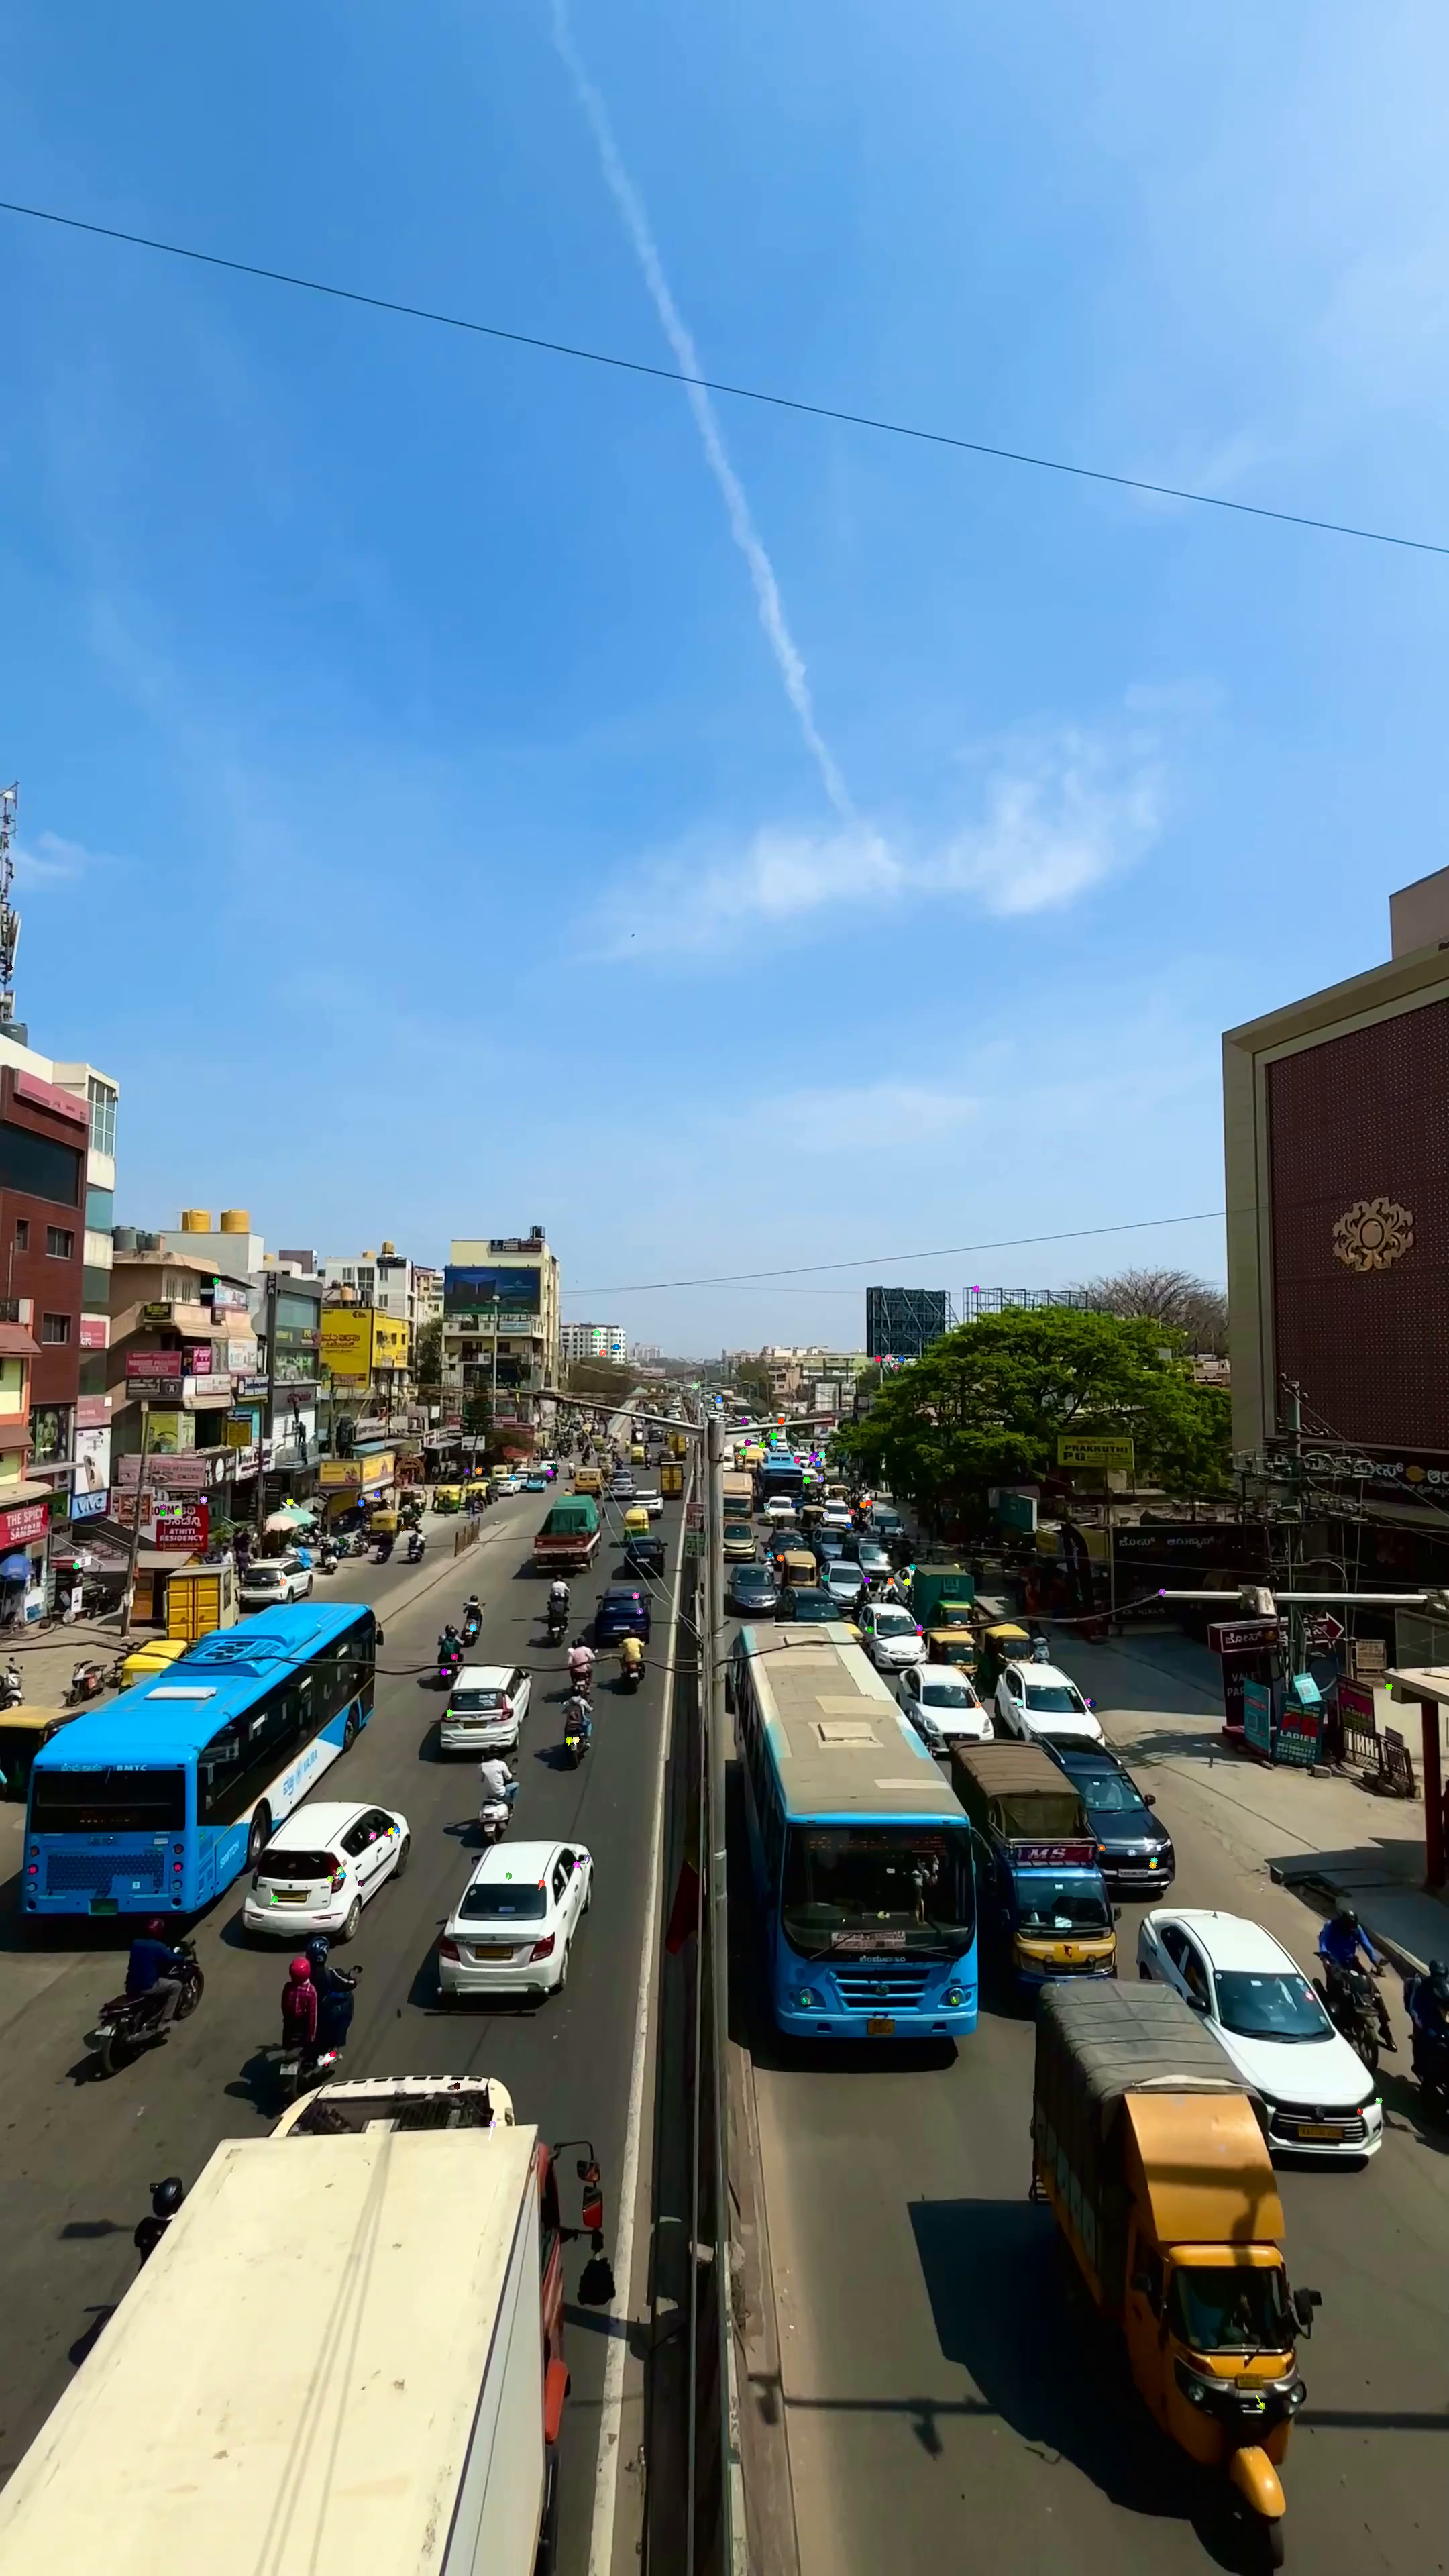

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def run_optical_flow(video_path):
    # Load video file
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video file")
        return

    feature_params = dict(
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )


    color = np.random.randint(0, 255, (100, 3))

    ret, old_frame = cap.read()

    if not ret:
        print("Error: Cannot read video frame")
        return

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    mask = np.zeros_like(old_frame)

    while True:
        ret, frame = cap.read()

        if not ret:
            print("End of video")
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

        if p1 is not None:

            good_new = p1[st == 1]
            good_old = p0[st == 1]

            for i, (new, old) in enumerate(zip(good_new, good_old)):
                a, b = new.ravel()
                c, d = old.ravel()

                mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
                frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)

            img = cv2.add(frame, mask)

            cv2_imshow(img)

            old_gray = frame_gray.copy()
            p0 = good_new.reshape(-1, 1, 2)

        if cv2.waitKey(30) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()

run_optical_flow("trafic.mp4")